In [ ]:
#### optimize the f1 score
#### apply imbalance optimization techniques on the ANN 
#### same notebook from the ANN folder
#### using an ANN to predict customer churn rates
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
## Data Exploration
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [4]:
df.drop("customerID", axis=1, inplace=True) if "customerID" in df else print("Already removed")
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df.TotalCharges.values # string object

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(7043,), dtype=object)

In [6]:
## Treat empty entries

pd.to_numeric(df.TotalCharges, errors='coerce').isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: TotalCharges, Length: 7043, dtype: bool

In [7]:
df[pd.to_numeric(df.TotalCharges, errors='coerce').isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
df[df.TotalCharges != ' '].shape

(7032, 20)

In [9]:
df1 = df[df.TotalCharges!=' ']
df1.shape

(7032, 20)

In [10]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

In [11]:
df1.TotalCharges.values

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ],
      shape=(7032,))

In [12]:
df1[df1.Churn=='No'].head() # customers who are NOT leaving

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No


In [13]:
### visualizing the tenure of a customer to know loyalty trend

tenure_no = df1[df1.Churn=='No'].tenure   # customer is staying
tenure_yes = df1[df1.Churn=='Yes'].tenure # customer is leaving
tenure_yes

2        2
4        2
5        8
8       28
13      49
        ..
7021    12
7026     9
7032     1
7034    67
7041     4
Name: tenure, Length: 1869, dtype: int64

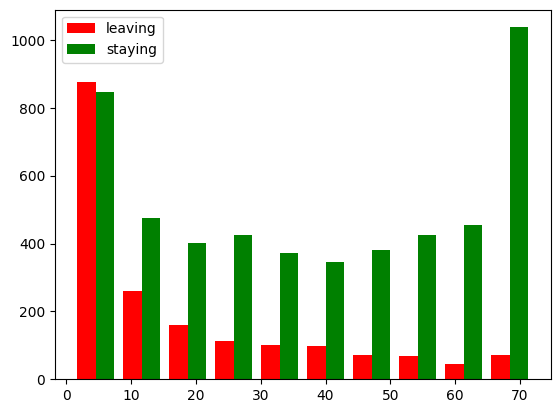

In [14]:
plt.hist([tenure_yes, tenure_no],color=['r','g'],label=['leaving','staying'])
plt.legend()

In [15]:
def get_unique(df):
    for col in df:
        if df[col].dtypes=='object':
            print("{} : {}".format(col, df[col].unique()))

In [16]:
get_unique(df1)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [17]:
### we can replace the verbose No's with a simple No

df1.replace('No phone service','No',inplace=True)
df1.replace('No internet service','No',inplace=True)

In [18]:
get_unique(df1)

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes']
OnlineBackup : ['Yes' 'No']
DeviceProtection : ['No' 'Yes']
TechSupport : ['No' 'Yes']
StreamingTV : ['No' 'Yes']
StreamingMovies : ['No' 'Yes']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


In [19]:
### replacing text with nums
## yes and no can be encoded to 0 and 1

y_n_cols = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

for col in y_n_cols:
    df1[col].replace({'Yes' : 1, 'No' : 0}, inplace=True)

In [20]:
get_unique(df1)

gender : ['Female' 'Male']
InternetService : ['DSL' 'Fiber optic' 'No']
Contract : ['Month-to-month' 'One year' 'Two year']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [21]:
for feature in df1:
    print(f"{feature} : {df1[feature].unique()}")

gender : ['Female' 'Male']
SeniorCitizen : [0 1]
Partner : [1 0]
Dependents : [0 1]
tenure : [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService : [0 1]
MultipleLines : [0 1]
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : [0 1]
OnlineBackup : [1 0]
DeviceProtection : [0 1]
TechSupport : [0 1]
StreamingTV : [0 1]
StreamingMovies : [0 1]
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : [1 0]
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges : [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges : [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn : [0 1]


In [22]:
### encoding gender

df1['gender'].replace({'Female' : 1, 'Male' : 0}, inplace=True)

In [23]:
### onehotencoding categorical variables using dummy vars

col_enc = ['InternetService', 'Contract', 'PaymentMethod']
df_enc = pd.get_dummies(data=df1, columns=col_enc)
df_enc.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,True,False,False,False,True,False,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,True,False,False,True,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,True,False,False,False,True,False,True,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False


In [24]:
df_enc.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No             

In [25]:

for col in df_enc:
    print(f'{col}: {df_enc[col].unique()}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
PaperlessBilling: [1 0]
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn: [0 1]
InternetService_DSL: [ True False]
InternetService_Fiber optic: [False  True]
InternetService_No: [False  True]
Contract_Month-to-month: [ True False]
Contract_One year: [False  True]
Contract_Two year: [False  True]
PaymentMethod_Bank transfer (automatic): [False  True]
PaymentMethod_Credit card (automatic): [False  True]
PaymentMethod_Electronic check: [ True False]
Pa

In [26]:
### Data split 

X = df_enc.drop('Churn', axis=1)
y = df_enc['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
X_train.shape

(4922, 26)

In [28]:
y_train.shape

(4922,)

In [29]:
X_train[:5]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3946,1,0,0,0,9,0,0,1,0,1,...,True,False,False,True,False,False,False,False,False,True
3394,0,0,0,0,26,1,1,1,1,0,...,True,False,False,False,True,False,False,False,True,False
1635,1,0,0,0,3,1,0,0,0,1,...,True,False,False,False,True,False,False,False,True,False
4088,0,0,0,0,7,1,1,0,0,0,...,False,True,False,True,False,False,False,False,True,False
1886,0,0,1,1,67,1,0,1,0,1,...,True,False,False,False,False,True,True,False,False,False


In [30]:
len(X_train.columns)

26

In [31]:
### ANN using tensorflow and keras

model = keras.Sequential([
    keras.layers.Dense(26, input_shape=(26,), activation='relu'),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(1, input_shape=(26,), activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=100)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6373 - loss: 15.7276  
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.7408 - loss: 0.6407
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.7383 - loss: 0.8381
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - accuracy: 0.7574 - loss: 0.6458
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 972us/step - accuracy: 0.7670 - loss: 0.5494
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7594 - loss: 0.7651  
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7617 - loss: 0.7298
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.7613 - loss: 0.6469
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 985us/step - accuracy: 0.7668 - loss: 0.6635
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1000us/step - accuracy: 0.7757 - loss: 0.5389
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - accuracy: 0.7802 - loss: 0.5627
Epoch 12/100
154/15

In [32]:
model.evaluate(X_test, y_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.7730 - loss: 0.4474


[0.4473893642425537, 0.7729857563972473]

In [33]:
y_pred = model.predict(X_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step


In [34]:
y_pred[:5]

array([[0.01145163],
       [0.16405492],
       [0.82816565],
       [0.18570031],
       [0.2840136 ]], dtype=float32)

In [35]:
y_test[:5]

2481    0
6784    0
6125    1
3052    0
4099    0
Name: Churn, dtype: int64

In [36]:
y_pred_bin = []
for pred in y_pred:
    if pred > 0.5:
        y_pred_bin.append(1)
    else:
        y_pred_bin.append(0)

In [37]:
y_pred_bin[:5]

[0, 0, 1, 0, 0]

In [38]:
### classification report

print(classification_report(y_test, y_pred_bin))


              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1549
           1       0.56      0.67      0.61       561

    accuracy                           0.77      2110
   macro avg       0.72      0.74      0.73      2110
weighted avg       0.79      0.77      0.78      2110


Text(50.722222222222214, 0.5, 'true')

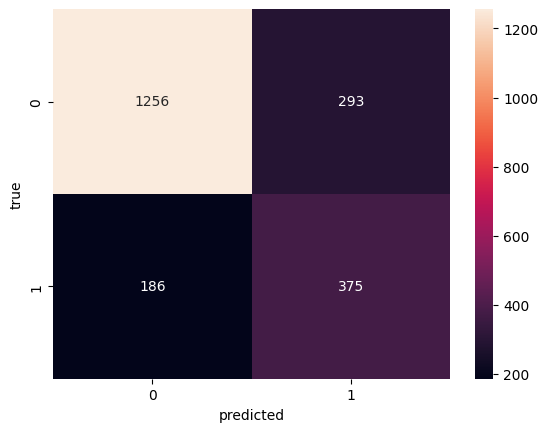

In [39]:
### confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred_bin)
sns.heatmap(conf_matrix, annot=True, fmt='d')
plt.xlabel("predicted")
plt.ylabel("true")

In [40]:
### Accuracy Calculation manula

round((1483+190)/(1483+66+371+190), 2)

0.79

In [41]:
### Precision for 0 class ---> no churn

round(1483/(371+1483), 2)

0.8

In [42]:
### Precision for 1 class ---> churned

round(190 /(66+190), 2)

0.74

In [43]:
### recall for class 0

round(1483/(66+1483), 2)

0.96

In [44]:
### recall for class 1

round(190/(190+371), 2)

0.34

In [48]:
def ANN(X_train, y_train, X_test, y_test, loss, weights):
    
    model = keras.Sequential([
    keras.layers.Dense(26, input_shape=(26,), activation='relu'),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(1, input_shape=(26,), activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )

    if weights == -1:
        model.fit(X_train, y_train, epochs=100)
    else:
        model.fit(X_train, y_train, epochs=100, class_weight=weights)

    print(model.evaluate(X_test, y_test))
    y_pred = model.predict(X_test)
    y_pred = np.round(y_pred)

    print("classification report: \n", classification_report(y_test, y_pred))

    return y_pred

In [ ]:
## bad f1 score for regular model with no optimization technique applied
new_predictions = ANN(X_train, y_train,\
                      X_test,y_test,\
                      'binary_crossentropy', -1)

Epoch 1/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.6701 - loss: 23.0123
Epoch 2/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - accuracy: 0.7379 - loss: 0.9018
Epoch 3/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.7383 - loss: 1.2016
Epoch 4/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 890us/step - accuracy: 0.7460 - loss: 0.9809
Epoch 5/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7582 - loss: 0.8285  
Epoch 6/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7562 - loss: 0.9984  
Epoch 7/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7645 - loss: 0.9692
Epoch 8/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.7548 - loss: 1.0073
Epoch 9/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.7694 - loss: 0.6910
Epoch 10/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - accuracy: 0.7680 - loss: 0.7006
Epoch 11/100
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.7692 - loss: 0.7095
Epoch 12/100
154/154

### 1 - under sampling technique

In [ ]:
count_class_0, count_class_1 = df1.Churn.value_counts() 

df_class0 = df_enc[df_enc['Churn']==0]
df_class1 = df_enc[df_enc['Churn']==1]

In [52]:
df_class0.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,True,False,False,True,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,True,False,False,False,True,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,True,False,False,False,True,False,True,False,False,False
6,0,0,0,1,22,1,1,0,1,0,...,False,True,False,True,False,False,False,True,False,False
7,1,0,0,0,10,0,0,1,0,0,...,True,False,False,True,False,False,False,False,False,True


In [ ]:
print(df_class0.shape)
print(df_class1.shape)
### shape imbalance visible.

(5163, 27)
(1869, 27)


In [62]:
### now we can use pd sample function to chunk out a portion of class 0 samples to have equal samples as in class 1

df_under_class0 = df_class0.sample(count_class_1)
df_under_class0.shape

(1869, 27)

In [64]:
# now class 0 has been undersampled and we can use only 1800 samples from class 0 instead of the initial 5000
# concat the 2 dfs into a new undersampled df

df_undersampled = pd.concat([df_under_class0, df_class1], axis=0)
df_undersampled.Churn.value_counts()

Churn
0    1869
1    1869
Name: count, dtype: int64

In [66]:
X_und = df_undersampled.drop('Churn', axis=1)
y_und = df_undersampled['Churn']

X_train, X_test, y_train, y_test = train_test_split(X_und, y_und, test_size=0.2, random_state=42, stratify=y_und)

In [ ]:
#### Much better F1 score ---> 0.75 for class 1 since more balanced dataset

predictions_undersampled = ANN(X_train, y_train, X_test, y_test,
                               'binary_crossentropy', -1)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6612 - loss: 2.8070  
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6916 - loss: 0.9589  
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6803 - loss: 1.2242  
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - accuracy: 0.7090 - loss: 0.7505
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - accuracy: 0.7201 - loss: 0.7578
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6967 - loss: 0.8496
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7040 - loss: 0.8721
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7124 - loss: 0.8163
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7214 - loss: 0.6915
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7425 - loss: 0.5842
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7067 - loss: 0.9279  
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step